# Reproduce Sections III &amp; V

**Switching-Reference Voltage Control for Distribution Systems with AI-Training Data Centers**: motivation figures (Figs 1-2) + Tables I/II + Figs 3-6.

## Setup

In [1]:
import sys, json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Locate the switchref/ repo root so the package is importable whether
# the notebook is launched from the repo root or this folder.
# (Skipped automatically once `pip install -e .` is run from the repo.)
HERE = Path.cwd()
ROOT = HERE if (HERE / 'switchref').is_dir() else HERE.parent
sys.path.insert(0, str(ROOT))

from switchref import (
    setup_common, setup_two_bus,
    load_h200_regulated, load_two_bus,
    action_linear, AdaRefVBiasAmpMaxDV,
    closed_loop, closed_loop_two_bus,
    compute_metrics,
    set_seed, make_dP_last_multi_square,
    # Constants (see switchref/config.py)
    SEED, ALPHA, BETA, GAMMA, C_RATE, ETA_B,
    K_SCALE, DEADBAND, STRIDE_CTRL, DT,
    TRACES, T_CYCLE_H200, TRACE_DIR,
)
from switchref.plotting import (
    plot_publication_scenario_2col,
    plot_publication_loadsmooth_sc,
    SUB_BUSES_DEFAULT,
)

FIG_DIR = ROOT / 'figures'
FIG_DIR.mkdir(exist_ok=True)
print('Imports OK.')

Imports OK.


# Reproduce Section III (motivation)

The two figures below motivate the method and are independent of the Section V experiments; they read the bundled `data/traces/dgx_h100_choukse.csv` and the IEEE 33-bus model, so they can be run right after Setup.

## Fig 1: raw training-power trace

Single-rack DGX-H100 trace from Choukse 2025 (arXiv:2508.14318). Compute and communication phases are shaded; the transition magnitude is $\Delta P_{\mathrm{dc}}$. Saved to `figures/fig1_raw_train_power.pdf`.

-> figures/fig1_raw_train_power.pdf


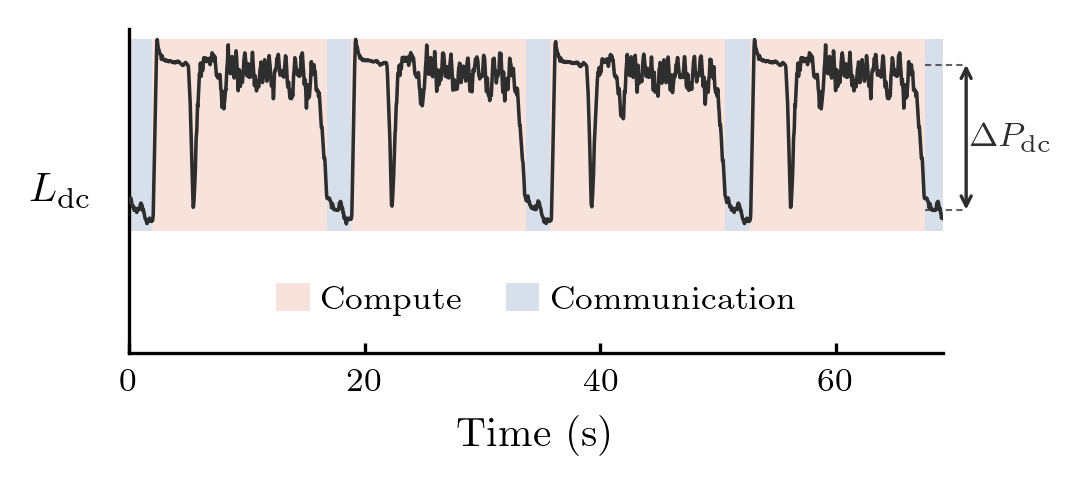

In [2]:
from matplotlib.patches import Rectangle, Patch

plt.rcParams.update({
    'text.usetex': True,
    'text.latex.preamble': r'\usepackage{amsmath}\usepackage{bm}',
    'font.family': 'serif',
})

df = pd.read_csv(TRACE_DIR / 'dgx_h100_choukse.csv')
t0 = df['time_s'].iloc[0]
t_sys = df['time_s'] - t0
p_sys = df['gpu_power_norm']
sl = slice(307, 1700)
t_plot = t_sys[sl].to_numpy(); t_plot = t_plot - t_plot[0]
p_plot = p_sys[sl].to_numpy() / float(p_sys[sl].max())

WARM_RED, COOL_BLUE, P_COLOR = '#E89F8C', '#7B98BD', '0.18'
WARM_A, COOL_A = 0.30, 0.30

fig, ax = plt.subplots(figsize=(3.5, 1.40), dpi=300)

# Phase shading: smooth the trace, threshold at the mid-level, and bracket each
# above/below run as a compute / communication band.
window_n = 30
p_smooth = np.convolve(p_plot, np.ones(window_n) / window_n, mode='same')
above = p_smooth > 0.5
trans_idx = np.where(np.diff(above.astype(np.int8)) != 0)[0] + 1

compute_periods, comm_periods = [], []
state = bool(above[0]); prev = 0
for idx in trans_idx:
    period = (float(t_plot[prev]), float(t_plot[idx]))
    (compute_periods if state else comm_periods).append(period)
    state = not state; prev = idx
final = (float(t_plot[prev]), float(t_plot[-1]))
(compute_periods if state else comm_periods).append(final)

ax.set_ylim(-0.25, 1.04)
ymin_data, ymax_data = float(p_plot.min()), float(p_plot.max())
shade_low = ymin_data - 0.04 * (ymax_data - ymin_data)
shade_h = 1.0 - shade_low
for a, b in compute_periods:
    ax.add_patch(Rectangle((a, shade_low), b - a, shade_h,
                           facecolor=WARM_RED, alpha=WARM_A, lw=0, zorder=1))
for a, b in comm_periods:
    ax.add_patch(Rectangle((a, shade_low), b - a, shade_h,
                           facecolor=COOL_BLUE, alpha=COOL_A, lw=0, zorder=1))
ax.plot(t_plot, p_plot, color=P_COLOR, lw=0.85, zorder=3)

# Delta P bracket on the last compute -> communication transition.
_fall_idx = np.where(np.diff(above.astype(np.int8)) < 0)[0]
if len(_fall_idx) >= 2:
    t_trans = float(t_plot[_fall_idx[-1] + 1]); fi = _fall_idx[-1]
    pre_idx = max(0, fi - 20); post_idx = min(len(p_plot) - 1, fi + 20)
    y_high = float(p_plot[pre_idx]); y_low = float(p_plot[post_idx])
    x_arrow = float(t_plot[-1]) + 2.0
    ax.plot([t_trans, x_arrow], [y_high, y_high], color=P_COLOR, lw=0.5,
            ls=(0, (3, 2)), alpha=0.75, zorder=2.5, clip_on=False)
    ax.plot([t_trans, x_arrow], [y_low, y_low], color=P_COLOR, lw=0.5,
            ls=(0, (3, 2)), alpha=0.75, zorder=2.5, clip_on=False)
    ax.annotate('', xy=(x_arrow, y_high), xytext=(x_arrow, y_low),
                arrowprops=dict(arrowstyle='<->', color=P_COLOR, lw=0.8,
                                shrinkA=0, shrinkB=0, mutation_scale=6),
                annotation_clip=False)
    ax.text(x_arrow + 0.3, 0.5 * (y_high + y_low), r'$\Delta P_{\mathrm{dc}}$',
            color=P_COLOR, ha='left', va='center', fontsize=8,
            fontstyle='italic', zorder=10, clip_on=False)

ax.set_yticks([])
handles = [Patch(facecolor=WARM_RED, alpha=WARM_A, lw=0, label='Compute'),
           Patch(facecolor=COOL_BLUE, alpha=COOL_A, lw=0, label='Communication')]
leg = ax.legend(handles=handles, loc='lower center', bbox_to_anchor=(0.5, 0.06),
                frameon=False, fontsize=8, handlelength=1.0, handleheight=0.9,
                handletextpad=0.35, ncol=2, columnspacing=1.3, borderaxespad=0.15)
for txt in leg.get_texts():
    txt.set_fontstyle('italic')
ax.set_xlabel('Time (s)', fontsize=10)
ax.set_ylabel(r'$L_\text{dc}$', fontsize=10, rotation=0, va='center', ha='right', labelpad=9)
ax.tick_params(labelsize=8, direction='in', length=2.5, width=0.8)
ax.spines[['top', 'right']].set_visible(False)
ax.set_xticks(np.arange(0, float(t_plot[-1]) + 1, 20))
ax.set_xlim(float(t_plot[0]), float(t_plot[-1]))

out_fig1 = FIG_DIR / 'fig1_raw_train_power.pdf'
plt.savefig(out_fig1, format='pdf', bbox_inches='tight', pad_inches=0.02)
print('-> figures/fig1_raw_train_power.pdf')
plt.show()

### Fig 2: power-to-voltage causality

An idealized two-level load at the data-center bus isolates the power-to-voltage step relation from the intra-phase fluctuations present in the measured traces. A load step $\Delta P_{\mathrm{dc}}$ produces a voltage step $\Delta V_{\mathrm{dc}} = R_{jj}\Delta P_{\mathrm{dc}}$; the bus voltage steps down at $t_a$ (communication-to-compute) and up at $t_b$ (compute-to-communication). Fixed-reference droop (b) sees the full step as the worst deviation; the switching reference (c) splits it evenly about nominal, halving the worst deviation to $\tfrac12\Delta V_{\mathrm{dc}}$. Saved to `figures/fig2_Pload_cause_V_effect.pdf`.

-> figures/fig2_Pload_cause_V_effect.pdf


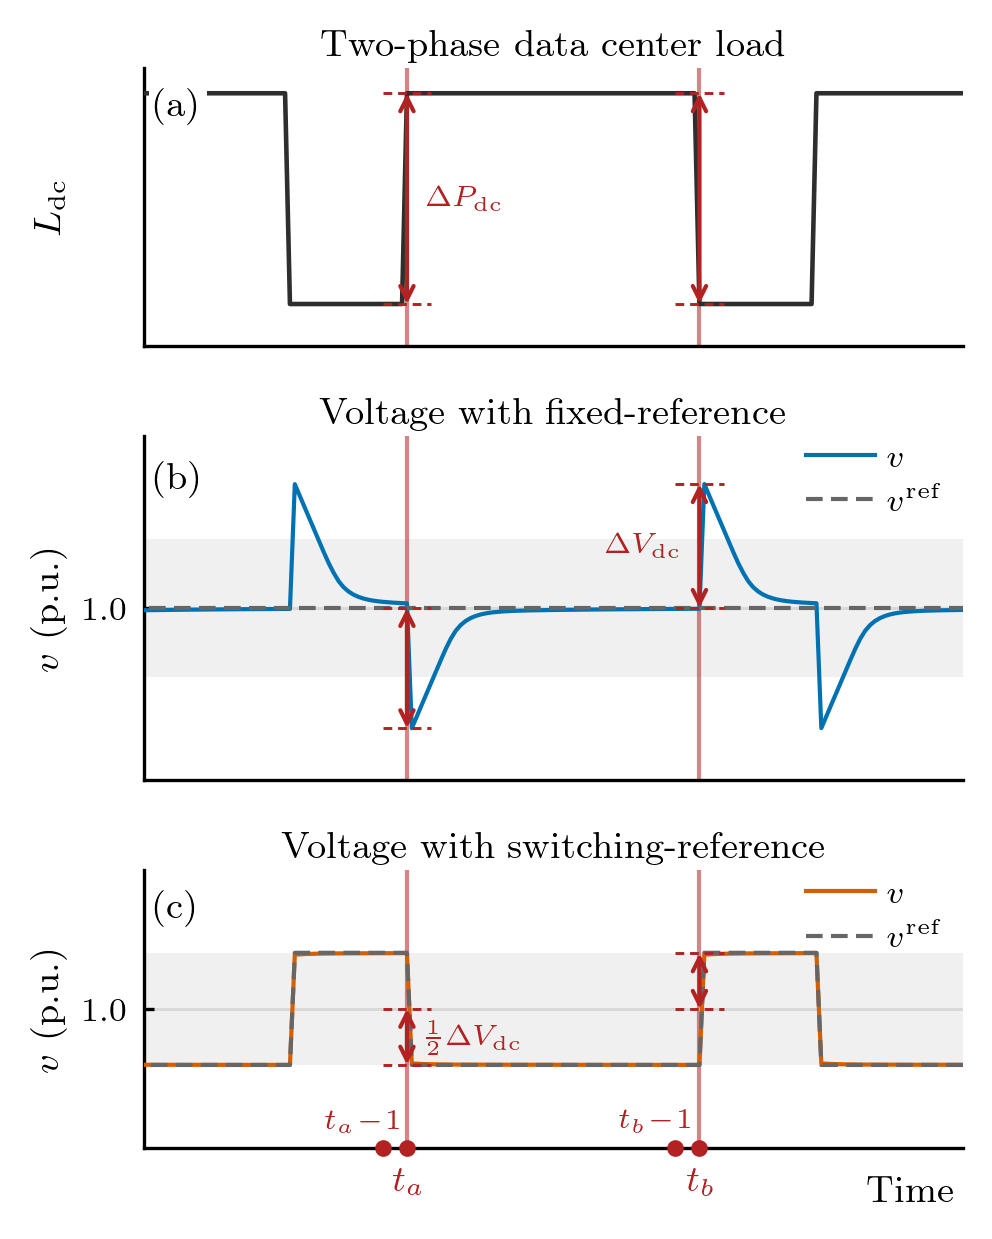

In [3]:
ctx = setup_common()
R_dc_self = ctx['R_dc_self']; R_dc_row = ctx['R_dc_row']
num_buses = ctx['num_buses']; dc_bus = ctx['dc_bus']
env = ctx['env']; P0 = ctx['P0']; P0_INIT = ctx['P0_INIT']
linear_coff = ctx['K']

cut, compute, communicate = 200, 60, 24
stride_ctrl, gain_scale, deadband, TH = 1, 50, 0.0, 0.1
vref = (R_dc_row / R_dc_row[dc_bus]) * 0.025
vref = np.asarray(vref, dtype=np.float32).reshape(num_buses, 1)
stages = [{'amp': 0.045 / R_dc_self, 'T_on': compute, 'T_off': communicate, 'cycles': 5}]
dP_last, T_sys = make_dP_last_multi_square(start=cut + communicate, stages=stages)


def run_sim(policy, crop_offset=10):
    # Per-step saturation u_max=0.01 must stay active: it gives panel (c) its
    # clean square. Disabling it lets the high-gain droop over-correct at each
    # transition, reintroducing overshoot hooks.
    set_seed(SEED, verbose=False)
    V = env.reset(P=P0_INIT, balance_Q=True)
    V_log = [V.squeeze().copy()]; P_log, R_log = [], []; P_dc = 0.0
    for k in range(T_sys):
        dP = -dP_last(k); P_dc -= dP
        dP_t = np.zeros_like(P0); dP_t[dc_bus, 0] = dP
        V_ref = policy(k, P_dc); R_log.append(V_ref.squeeze().copy())
        dQ = np.zeros((num_buses, 1), dtype=np.float32)
        if k % stride_ctrl == 0:
            dQ = action_linear(V, linear_coff * gain_scale, V_ref,
                               deadband=deadband, u_max=0.01
                               ).reshape(num_buses, 1).astype(np.float32)
        V = env.step(dQ, dP=dP_t)
        P_log.append(P_dc); V_log.append(V.squeeze().copy())
    P_arr = np.asarray(P_log, np.float32); V_arr = np.asarray(V_log, np.float32)
    R_arr = np.asarray(R_log, np.float32)
    s = cut + crop_offset; e = -communicate
    P_c, V_c, R_c = P_arr[s:e], V_arr[s:e], R_arr[s:e]
    tP = env.dt * np.arange(P_c.shape[0]); tV = env.dt * np.arange(V_c.shape[0])
    tR = tV[1:1 + R_c.shape[0]]
    return P_c, V_c, R_c, tP, tV, tR


P_fix, V_fix, R_fix, tP, tV, tR = run_sim(lambda k, P: np.zeros((num_buses, 1), np.float32))
P_sw, V_sw, R_sw, _, _, _ = run_sim(lambda k, P: ((+1 if P <= TH else -1) * vref).astype(np.float32))

V0_fix = V_fix[0, dc_bus]
dV_fix_dc = (V_fix[:, dc_bus] - V0_fix).astype(np.float32)
dVref_fix_dc = (R_fix[:, dc_bus] - V0_fix).astype(np.float32)
dV_sw_dc = V_sw[:, dc_bus].astype(np.float32)
dVref_sw_dc = R_sw[:, dc_bus].astype(np.float32)

P_C2, Z_COLOR, T_COLOR = '0.18', '#0072B2', '#D55E00'
REF_COLOR = '0.40'; REF_DASH = (0, (4, 2)); BASELINE_COLOR = '0.85'
ACCENT, BAND_COLOR = '#B22222', '0.92'

fig, (axP, axB, axC) = plt.subplots(
    3, 1, figsize=(3.5, 4.0), dpi=300, sharex=True,
    gridspec_kw={'height_ratios': [0.85, 1.05, 0.85], 'hspace': 0.30})
fig.subplots_adjust(left=0.18, right=0.96, top=0.97, bottom=0.07, hspace=0.30)


def panel_tag(ax, tag):
    ax.text(0.012, 0.93, tag, transform=ax.transAxes, ha='left', va='top',
            fontweight='bold', fontsize=9, zorder=50,
            bbox=dict(boxstyle='square,pad=0.12', facecolor='white', edgecolor='none'))


def fmt(ax, ylabel, hide_x=True):
    ax.set_ylabel(ylabel, fontsize=9)
    ax.tick_params(labelsize=8, direction='in', length=2.5, width=0.8)
    if hide_x:
        ax.tick_params(axis='x', which='both', bottom=False, labelbottom=False)
    ax.spines[['top', 'right']].set_visible(False)


axP.plot(tP, P_fix, color=P_C2, lw=1.1, zorder=3)
fmt(axP, r'$L_\text{dc}$'); panel_tag(axP, '(a)'); axP.set_yticks([])
axP.set_title('Two-phase data center load', fontsize=9, pad=3)
ymin_p, ymax_p = float(P_fix.min()), float(P_fix.max())
axP.set_ylim(ymin_p - 0.20 * (ymax_p - ymin_p), ymax_p + 0.12 * (ymax_p - ymin_p))

BAND = 0.025
axB.axhspan(-BAND, +BAND, color=BAND_COLOR, alpha=0.7, lw=0, zorder=0.3)
axB.axhline(0.0, color=BASELINE_COLOR, lw=0.7, zorder=1)
hVb, = axB.plot(tV, dV_fix_dc, color=Z_COLOR, lw=1.0, zorder=4)
hRb, = axB.plot(tR, dVref_fix_dc, color=REF_COLOR, ls=REF_DASH, lw=1.0, zorder=8)
fmt(axB, r'$v$ (p.u.)'); panel_tag(axB, '(b)')
axB.set_title('Voltage with fixed-reference', fontsize=9, pad=3)
axB.set_yticks([0.0]); axB.set_yticklabels(['1.0'], fontsize=8)
axB.legend([hVb, hRb], [r'$v$', r'$v^{\mathrm{ref}}$'], loc='upper right',
           bbox_to_anchor=(1.0, 1.04), fontsize=7.5, frameon=False,
           handlelength=2.2, handletextpad=0.4, borderaxespad=0.3)

axC.axhspan(-BAND, +BAND, color=BAND_COLOR, alpha=0.7, lw=0, zorder=0.3)
axC.axhline(0.0, color=BASELINE_COLOR, lw=0.7, zorder=1)
hVc, = axC.plot(tV, dV_sw_dc, color=T_COLOR, lw=1.0, zorder=4)
hRc, = axC.plot(tR, dVref_sw_dc, color=REF_COLOR, ls=REF_DASH, lw=1.0, zorder=8)
fmt(axC, r'$v$ (p.u.)', hide_x=False); panel_tag(axC, '(c)')
axC.set_title('Voltage with switching-reference', fontsize=9, pad=3)
axC.set_yticks([0.0]); axC.set_yticklabels(['1.0'], fontsize=8)
axC.set_xlabel(''); axC.set_xticks([])
axC.tick_params(axis='x', which='both', bottom=False, labelbottom=False)
axC.legend([hVc, hRc], [r'$v$', r'$v^{\mathrm{ref}}$'], loc='upper right',
           bbox_to_anchor=(1.0, 1.04), fontsize=7.5, frameon=False,
           handlelength=2.2, handletextpad=0.4, borderaxespad=0.3)

ylim_v = 0.062
axB.set_ylim(-ylim_v, +ylim_v); axC.set_ylim(-ylim_v, +ylim_v)

diff_p = np.diff(P_fix)
thr = 0.5 * float(np.max(np.abs(diff_p)))
i_falls = np.flatnonzero(diff_p < -thr) + 1
i_rises = np.flatnonzero(diff_p > thr) + 1
i_up = int(i_rises[len(i_rises) // 2])
_falls_after = i_falls[i_falls > i_up]
i_down = int(_falls_after[0]) if len(_falls_after) else int(i_falls[-1])
t_up, t_down = float(tP[i_up]), float(tP[i_down])


def _spike(i_trans):
    iv = int(np.searchsorted(tV, float(tP[i_trans])))
    lo = max(0, iv - 1); hi = min(len(dV_fix_dc), iv + 8)
    win = dV_fix_dc[lo:hi]
    return float(dV_fix_dc[lo + int(np.argmax(np.abs(win)))])


def _step(i_trans, V):
    iv = int(np.searchsorted(tV, float(tP[i_trans])))
    return float(np.median(V[iv + 4: iv + 30]))


def _plevels(i_t):
    a, b = float(P_fix[i_t - 1]), float(P_fix[i_t])
    return min(a, b), max(a, b)


v_spike_d, v_spike_u = _spike(i_down), _spike(i_up)
v_step_d, v_step_u = _step(i_down, dV_sw_dc), _step(i_up, dV_sw_dc)
P_lo_d, P_hi_d = _plevels(i_down); P_lo_u, P_hi_u = _plevels(i_up)

DT_F2 = float(tP[1] - tP[0]) if len(tP) > 1 else 0.1
BR_HALF = 5 * DT_F2


def annot(ax, x, y0, y1, lbl, label_y, dx=0.6, ha='left'):
    ax.annotate('', xy=(x, y1), xytext=(x, y0),
                arrowprops=dict(arrowstyle='<->', color=ACCENT, lw=1.0,
                                shrinkA=0, shrinkB=0, mutation_scale=8),
                zorder=10, annotation_clip=False)
    for y in (y0, y1):
        ax.plot([x - BR_HALF, x + BR_HALF], [y, y], ls=(0, (3, 2)),
                color=ACCENT, lw=0.7, zorder=10, clip_on=False)
    ax.text(x + dx, label_y, lbl, color=ACCENT, ha=ha, va='center',
            fontsize=7, zorder=10, clip_on=False)


annot(axP, t_up, P_lo_u, P_hi_u, r'$\Delta P_{\mathrm{dc}}$', 0.5 * (P_lo_u + P_hi_u), dx=0.4, ha='left')
annot(axP, t_down, P_lo_d, P_hi_d, '', 0.5 * (P_lo_d + P_hi_d))
annot(axB, t_up, 0.0, v_spike_u, '', 0.5 * v_spike_u)
annot(axB, t_down, 0.0, v_spike_d, r'$\Delta V_{\mathrm{dc}}$', 0.5 * v_spike_d, dx=-0.4, ha='right')
annot(axC, t_up, 0.0, v_step_u, r'$\tfrac{1}{2}\Delta V_{\mathrm{dc}}$', 0.5 * v_step_u, dx=0.4, ha='left')
annot(axC, t_down, 0.0, v_step_d, '', 0.5 * v_step_d)

for _ax in (axP, axB, axC):
    _ax.axvline(t_down, color=ACCENT, alpha=0.55, lw=1.0, zorder=0.5, solid_capstyle='butt')
    _ax.axvline(t_up, color=ACCENT, alpha=0.55, lw=1.0, zorder=0.5, solid_capstyle='butt')

mid_t = 0.5 * (t_down + t_up)
HALF_VIEW = (compute + communicate) * DT_F2
axC.set_xlim(mid_t - HALF_VIEW, mid_t + HALF_VIEW)

yc_lo, yc_hi = axC.get_ylim(); yc_range = yc_hi - yc_lo


def _tick_below(tx, lbl):
    axC.plot([tx], [yc_lo], marker='o', color=ACCENT, markersize=3.0, clip_on=False, zorder=11)
    axC.text(tx, yc_lo - 0.06 * yc_range, lbl, ha='center', va='top',
             color=ACCENT, fontsize=9, clip_on=False)


def _tick_above(dot_x, lbl_x, lbl):
    axC.plot([dot_x], [yc_lo], marker='o', color=ACCENT, markersize=3.0, clip_on=False, zorder=11)
    axC.text(lbl_x, yc_lo + 0.05 * yc_range, lbl, ha='center', va='bottom',
             color=ACCENT, fontsize=7, clip_on=False)


# Neutral labels: t_a = the left transition (communication->compute, voltage down),
# t_b = the right transition (compute->communication, voltage up).
_tick_below(t_up, r'$t_a$')
_tick_below(t_down, r'$t_b$')
_tick_above(t_up - 5 * DT_F2, t_up - 9 * DT_F2, r'$t_a\!-\!1$')
_tick_above(t_down - 5 * DT_F2, t_down - 9 * DT_F2, r'$t_b\!-\!1$')
axC.text(0.99, -0.10, 'Time', transform=axC.transAxes, ha='right', va='top',
         fontsize=9, clip_on=False)
fig.align_ylabels([axP, axB, axC])

out_fig2 = FIG_DIR / 'fig2_Pload_cause_V_effect.pdf'
plt.savefig(out_fig2, format='pdf', bbox_inches='tight', pad_inches=0.02)
print('-> figures/fig2_Pload_cause_V_effect.pdf')
plt.show()

# Reproduce Section V (experiments)

Tables I/II and Figs 3-6 on the real AI-training power traces, all driven by the single dimensionless design rule below.

## Design rule

Four constants, identical across traces:

$$\alpha = 1, \quad \beta = 1, \quad \gamma = \tfrac{1}{8}, \quad c = \tfrac{1}{4}.$$

At $\Delta t_{\mathrm{ctrl}} = 1$&nbsp;s:

$$N_a\,\Delta t_{\mathrm{ctrl}} = \alpha\,T_{\mathrm{cycle}},\quad N_b\,\Delta t_{\mathrm{ctrl}} = \beta\,T_{\mathrm{cycle}},\quad D_b\,\Delta t_{\mathrm{ctrl}} = \gamma\,T_{\mathrm{cycle}},\quad \eta_b = c\,\gamma = \tfrac{1}{32}.$$

Only $T_{\mathrm{cycle}}$ varies per trace.

### Per-trace values

In [4]:
print(f'eta_b = {ETA_B:.5f}  (same for every trace)')
print()
print(f"{'Trace':<11}{'T_cycle':>10}{'N_a':>8}{'N_b':>8}{'D_b':>8}")
for name, cyc, _ in TRACES:
    print(f"{name:<11}{cyc:>10.0f}{ALPHA*cyc:>8.1f}{BETA*cyc:>8.1f}{GAMMA*cyc:>8.2f}")

eta_b = 0.03125  (same for every trace)

Trace         T_cycle     N_a     N_b     D_b
4xH200            132   132.0   132.0   16.50
4xA100            131   131.0   131.0   16.38
4xL40S            107   107.0   107.0   13.38
DGX-H100           17    17.0    17.0    2.12


## Runners

`run_fixed`: linear droop, $v^{\mathrm{ref}} = 1$ p.u. `run_switching`: AdaRefVBiasAmpMaxDV (Algorithm 1), cycle-derived $(N_a, N_b, D_b, \eta_b)$.

In [5]:
def run_fixed(ctx, ds):
    V0 = np.zeros((ctx['num_buses'], 1))
    return closed_loop(
        ctx=ctx, ds=ds,
        ctrl_step=lambda k, V: action_linear(V, ctx['K'] * K_SCALE, V0, deadband=DEADBAND),
        stride_ctrl=STRIDE_CTRL,
    )


def run_switching(ctx, ds, cycle_s):
    dt_ctrl = STRIDE_CTRL * ctx['dt_sys']      # 1 s
    N_a = max(1, int(round(ALPHA * cycle_s / dt_ctrl)))
    N_b = max(1, int(round(BETA  * cycle_s / dt_ctrl)))
    D_b = max(1, int(round(GAMMA * cycle_s / dt_ctrl)))
    ctrl = AdaRefVBiasAmpMaxDV(
        n=ctx['num_buses'], K=ctx['K'] * K_SCALE,
        action_kwargs={'deadband': DEADBAND},
        bias_len=N_b, bias_per=D_b, bias_frac=ETA_B,
        amp_win_len=N_a,
    )
    return closed_loop(ctx=ctx, ds=ds,
                       ctrl_step=lambda k, V: ctrl.step(V),
                       stride_ctrl=STRIDE_CTRL)


def run_nocontrol(ctx, ds):
    # Uncontrolled baseline: no reactive injection (Delta q == 0); the bus
    # voltage is driven purely by the data-center active-power swing.
    n_bus = ctx['num_buses']
    return closed_loop(ctx=ctx, ds=ds,
                       ctrl_step=lambda k, V: np.zeros((n_bus, 1), dtype=np.float32),
                       stride_ctrl=STRIDE_CTRL)

## Table I

Six-cycle warmup. Network-level metrics over $(i, t)$:

* `viol` $=$ RMS of $\max(|v_{i,t} - 1| - 0.05,\ 0)$.
* `eff` $=$ RMS of $\Delta q_{i,t}$.

In [6]:
table_rows = []
Vfix_store, dQfix_store = {}, {}
Vsw_store,  dQsw_store  = {}, {}
Vnone_store, dQnone_store = {}, {}

for name, cyc, loader in TRACES:
    warm = 6.0 * cyc

    ctx = setup_common(); ds = loader(ctx)
    dQf, Vf = run_fixed(ctx, ds)
    mf = compute_metrics(dQf, Vf, dt=ctx['env'].dt, warmup_secs=warm)

    ctx = setup_common(); ds = loader(ctx)
    dQs, Vs = run_switching(ctx, ds, cycle_s=cyc)
    ms = compute_metrics(dQs, Vs, dt=ctx['env'].dt, warmup_secs=warm)

    ctx = setup_common(); ds = loader(ctx)
    dQn, Vn = run_nocontrol(ctx, ds)
    mn = compute_metrics(dQn, Vn, dt=ctx['env'].dt, warmup_secs=warm)

    table_rows.append({
        'trace': name, 'cycle_s': cyc, 'warmup_s': warm,
        'none_viol': mn['rms_excess']*1e4, 'none_peak': mn['max_excess']*1e2,
        'fix_viol': mf['rms_excess']*1e4, 'fix_eff': mf['rms_dq']*1e4,
        'sw_viol':  ms['rms_excess']*1e4, 'sw_eff':  ms['rms_dq']*1e4,
    })
    Vfix_store[name], dQfix_store[name] = Vf, dQf
    Vsw_store[name],  dQsw_store[name]  = Vs, dQs
    Vnone_store[name], dQnone_store[name] = Vn, dQn

print('=' * 78)
print('Table I  (single-DC; values x1e-4 p.u.)')
print('=' * 78)
print(f"{'Trace':<12}{'Fix viol':>10}{'Sw viol':>10}{'violÃƒâ€”':>10}{'Fix eff':>10}{'Sw eff':>10}{'effÃƒâ€”':>10}")
for r in table_rows:
    vr = r['fix_viol'] / r['sw_viol'] if r['sw_viol'] > 1e-4 else float('inf')
    er = r['fix_eff']  / r['sw_eff']
    vrs = '>10^3' if vr == float('inf') or vr > 1e3 else f'{vr:.1f}x'
    print(f"{r['trace']:<12}{r['fix_viol']:>10.3f}{r['sw_viol']:>10.3f}{vrs:>10}"
          f"{r['fix_eff']:>10.3f}{r['sw_eff']:>10.3f}{er:>9.1f}x")

with open(FIG_DIR / 'table1_metrics.json', 'w') as f:
    json.dump({'design_rule': {'alpha': ALPHA, 'beta': BETA, 'gamma': GAMMA,
                               'c_rate': C_RATE, 'eta_b': ETA_B},
               'rows': table_rows}, f, indent=2)
print('\n-> figures/table1_metrics.json')

Table I  (single-DC; values x1e-4 p.u.)
Trace         Fix viol   Sw viol violÃƒâ€”   Fix eff    Sw eff  effÃƒâ€”
4xH200           3.918     0.234     16.7x     3.023     0.152     19.9x
4xA100           3.076     0.132     23.2x     2.826     0.449      6.3x
4xL40S           2.398     0.000     >10^3     2.978     0.233     12.8x
DGX-H100         3.420     0.245     14.0x     3.375     0.999      3.4x

-> figures/table1_metrics.json


## Fig 3: 4&times;H200 detail

-> figures/fig3_single_dc.pdf


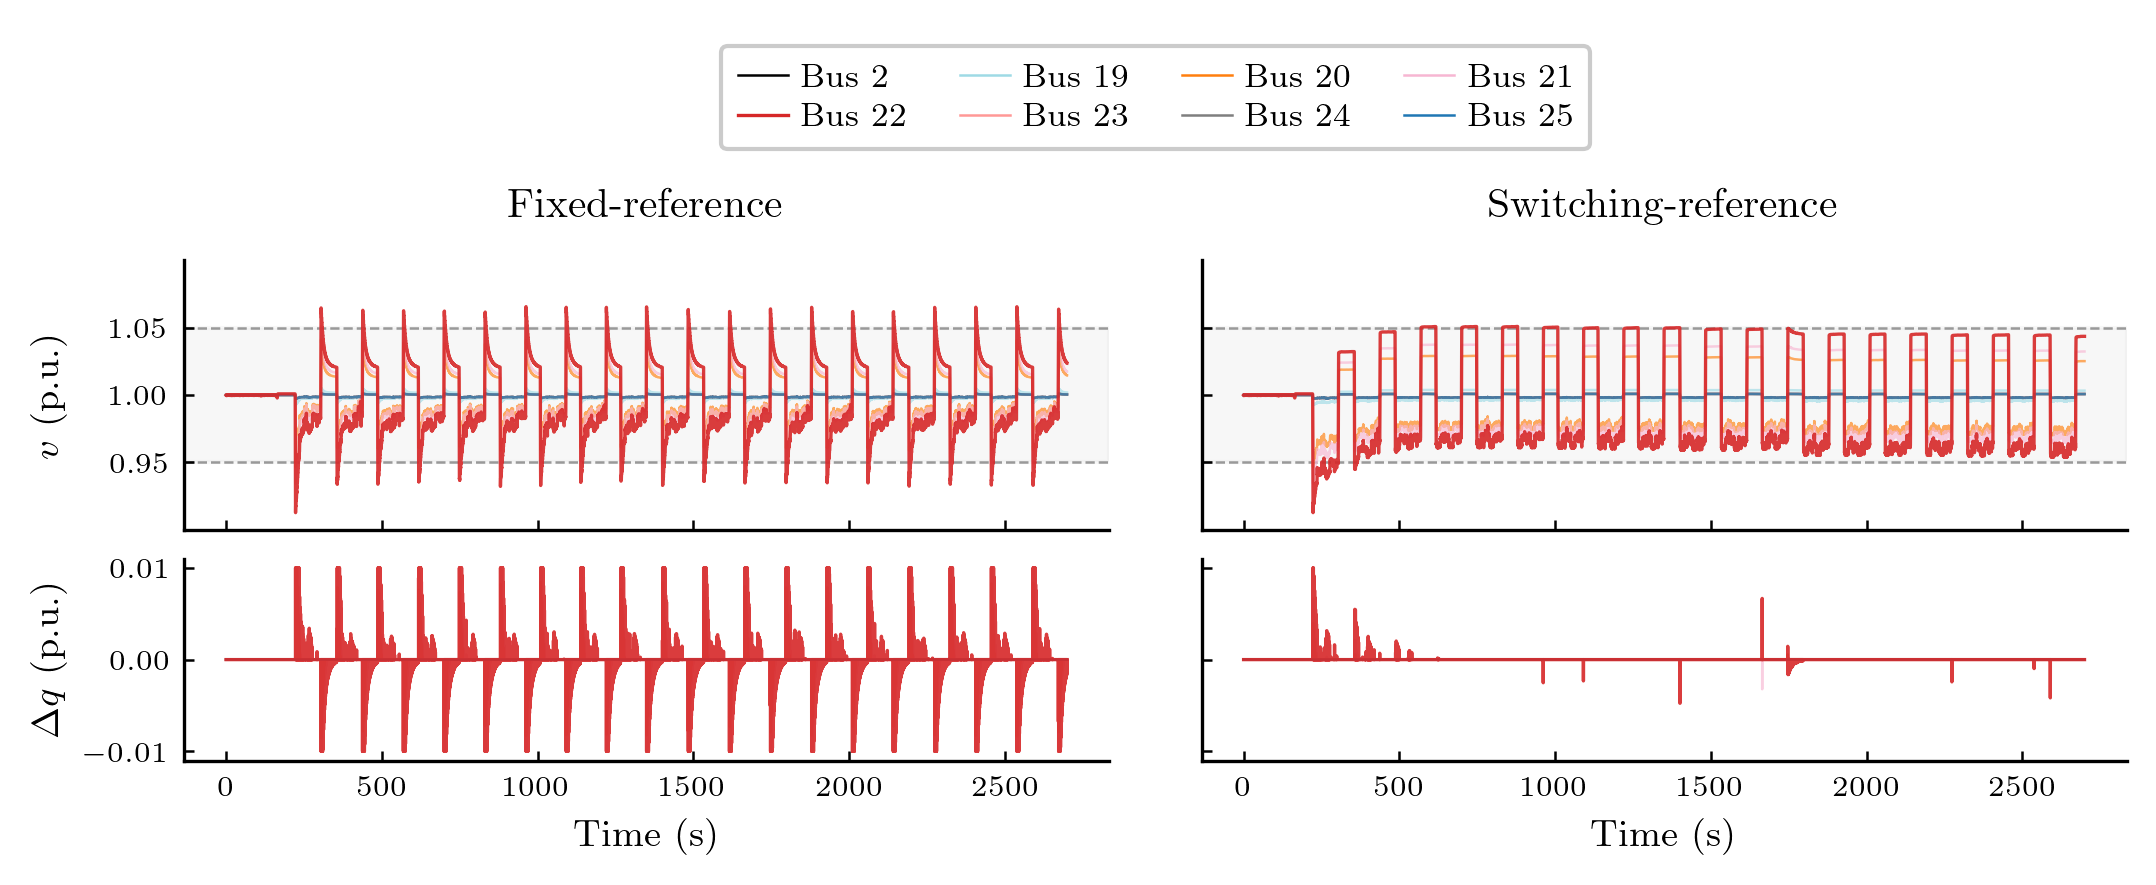

In [7]:
ctx_h200 = setup_common()
runs_h200 = [
    {'dQ': dQfix_store['4xH200'], 'V': Vfix_store['4xH200'], 'dc_buses': [ctx_h200['dc_bus']]},
    {'dQ': dQsw_store ['4xH200'], 'V': Vsw_store ['4xH200'], 'dc_buses': [ctx_h200['dc_bus']]},
]
out_fig3 = FIG_DIR / 'fig3_single_dc.pdf'
plot_publication_scenario_2col(
    runs_h200,
    bus_colors=ctx_h200['bus_colors'],
    plot_buses=SUB_BUSES_DEFAULT,
    save_path=str(out_fig3),
    dt=ctx_h200['env'].dt,
)
print('-> figures/fig3_single_dc.pdf')
plt.show()

## Fig 4: four-trace overlay

4&times;H200 / 4&times;A100 / 4&times;L40S / at-scale H100. Columns: load $L_{\mathrm{dc}}$, voltage $v$, control $\Delta q$. Per-row plot window is the 6-cycle segment with the largest fixed-reference band excursion (window endpoints are at compute-phase troughs).

-> figures/fig4_generalization.pdf


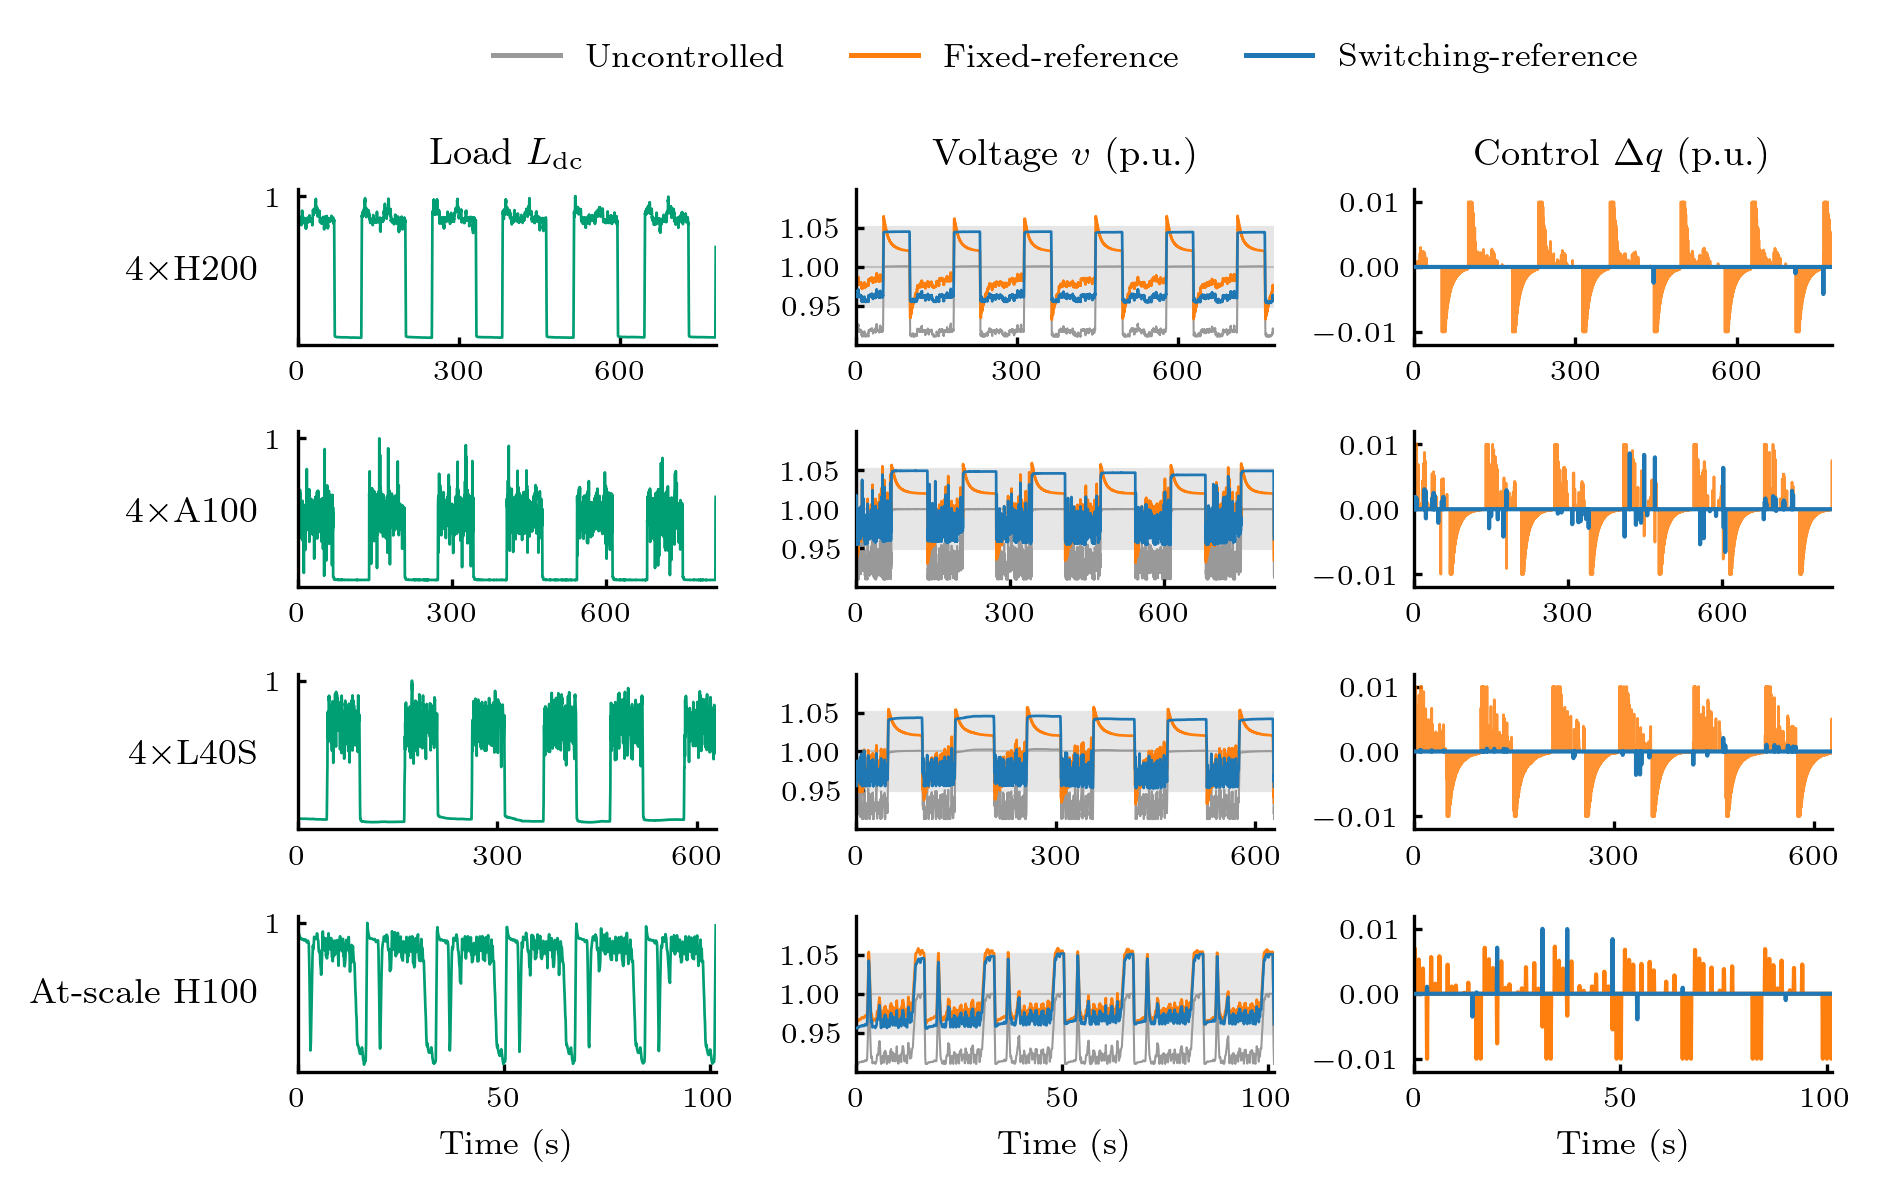

In [8]:
BUS = 20             # data-center bus (label 22)
# C_FIX = '#E69F00'    # Wong orange (colorblind-safe alternative)
# C_SW  = '#CC79A7'    # Wong reddish purple
C_FIX = '#ff7f0e'    # matplotlib tab:orange for fixed-reference
C_SW  = '#1f77b4'    # matplotlib tab:blue for switching-reference
C_PWR = '#009E73'    # Wong bluish-green for the (shared) data center load input
C_NONE = '0.6'       # gray backdrop for the uncontrolled voltage

from scipy.signal import find_peaks

# Row order matches the paper Table I: 4xH200, 4xA100, 4xL40S, at-scale H100.
# t0 is the lower bound under which the worst-violation window is searched.
EXPS_FIG4 = [
    ('4xH200',   132, 1000.0),
    ('4xA100',   131,  900.0),
    ('4xL40S',   107,  700.0),
    ('DGX-H100',  17,  150.0),
]

# Per-row display labels (leftmost-column y-axis label of each row).
ROW_LABEL = {'4xH200': r'$4\times$H200', '4xA100': r'$4\times$A100',
             '4xL40S': r'$4\times$L40S', 'DGX-H100': 'At-scale H100'}
N_CYC = 6
loaders = {name: loader for name, cyc, loader in TRACES}


def find_worst_violation_window(Vf, bus, cyc, dt, n_cyc, t_min):
    """Window = trough[i]..trough[i+n_cyc] of the fixed-reference V at `bus`
    that minimizes integrated band excess (representative steady-state stretch where typical controller response is visible without large transient spikes dominating the view). Both endpoints sit on compute-phase
    voltage troughs, so the window spans exactly n_cyc complete cycles."""
    v_bus = Vf[:, bus] + 1.0
    violation = np.maximum(np.abs(v_bus - 1.0) - 0.05, 0.0)
    troughs, _ = find_peaks(-Vf[:, bus], distance=int(0.6 * cyc / dt))
    tV = np.arange(len(Vf)) * dt
    troughs = troughs[tV[troughs] >= t_min]
    best_i, best_score = 0, np.inf
    for i in range(len(troughs) - n_cyc):
        s = float(np.sum(violation[troughs[i]:troughs[i + n_cyc]]))
        if s < best_score:
            best_score, best_i = s, i
    return tV[troughs[best_i]], tV[troughs[best_i + n_cyc]]


def find_worst_violation_window_load(P, tP, Vf, bus, tV, dt_pwr, cyc, n_cyc, t_min):
    """DGX-H100 voltage troughs are too irregular; align to load troughs instead
    and then advance to the first high-power point for visual cleanliness."""
    v_bus = Vf[:, bus] + 1.0
    violation = np.maximum(np.abs(v_bus - 1.0) - 0.05, 0.0)
    troughs, _ = find_peaks(-P, distance=int(0.6 * cyc / dt_pwr))
    troughs = troughs[tP[troughs] >= t_min]
    hi = np.percentile(P, 5) + 0.8 * (np.percentile(P, 95) - np.percentile(P, 5))
    best_i, best_score = 0, np.inf
    for i in range(len(troughs) - n_cyc):
        iA, iB = troughs[i], troughs[i + n_cyc]
        while iA < len(P) - 1 and P[iA] < hi: iA += 1
        while iB < len(P) - 1 and P[iB] < hi: iB += 1
        mask = (tV >= tP[iA]) & (tV <= tP[iB])
        if not mask.any():
            continue
        s = float(np.sum(violation[mask]))
        if s < best_score:
            best_score, best_i = s, i
    iA, iB = troughs[best_i], troughs[best_i + n_cyc]
    while iA < len(P) - 1 and P[iA] < hi: iA += 1
    while iB < len(P) - 1 and P[iB] < hi: iB += 1
    return tP[iA], tP[iB]


plt.rcParams.update({
    'text.usetex': True,
    'text.latex.preamble': r'\usepackage{amsmath}\usepackage{bm}',
    'font.family': 'serif',
})

fig, axes = plt.subplots(len(EXPS_FIG4), 3, figsize=(7.2, 1.0 * len(EXPS_FIG4)), dpi=300)
for r, (name, cyc, t0) in enumerate(EXPS_FIG4):
    Vf, dQf = Vfix_store[name], dQfix_store[name]
    Vs, dQs = Vsw_store [name], dQsw_store [name]
    Vn = Vnone_store[name]
    ds = loaders[name](setup_common())
    tV = np.arange(len(Vs)) * DT
    tq = np.arange(len(dQs)) * DT
    tP = ds['t_pwr']
    P = -np.asarray(ds['pwr_pwr'])

    if name == 'DGX-H100':
        dt_pwr = float(tP[1] - tP[0])
        tA, tB = find_worst_violation_window_load(P, tP, Vf, BUS, tV, dt_pwr, cyc, N_CYC, t0)
    else:
        tA, tB = find_worst_violation_window(Vf, BUS, cyc, DT, N_CYC, t0)
    if name == '4xH200':
        # Other rows start and end in the compute phase (load@endpoint high).
        # For 4xH200 the fixed-reference voltage trough falls in the
        # communication phase, so the trough-based window started at a low-load
        # point, out of phase. Re-anchor on the load compute plateaus to
        # reproduce the same high-load endpoints: hysteresis comm->compute rising
        # edges, the N_CYC-cycle span nearest the auto window, then a small step
        # into the plateau so the row starts at high power and ends right at the
        # closing step increase, matching the 4xA100/4xL40S rows.
        rng = P.max() - P.min()
        hi_th, lo_th = P.min() + 0.6 * rng, P.min() + 0.4 * rng
        rises, hs = [], bool(P[0] > hi_th)
        for i in range(1, len(P)):
            if not hs and P[i] > hi_th:
                rises.append(tP[i]); hs = True
            elif hs and P[i] < lo_th:
                hs = False
        rises = np.asarray([rr for rr in rises if rr >= t0])
        j = int(np.argmin(np.abs(rises - tB)))
        i0 = max(0, j - N_CYC)
        off_start, off_end = 0.10 * cyc, 0.0
        tA = float(rises[i0] + off_start)
        tB = float(rises[j] + off_end)

    mV = (tV >= tA) & (tV <= tB)
    mq = (tq >= tA) & (tq <= tB)
    mP = (tP >= tA) & (tP <= tB)

    axP, axV, axQ = axes[r, 0], axes[r, 1], axes[r, 2]

    Pw = P[mP]
    Pw = (Pw - Pw.min()) / (Pw.max() - Pw.min() + 1e-12)
    axP.plot(tP[mP] - tA, Pw, color=C_PWR, lw=0.65)
    axP.set_ylim(-0.05, 1.05)
    axP.set_yticks([1]); axP.set_yticklabels(['1'])
    axP.set_ylabel(ROW_LABEL.get(name, name), fontsize=8.5, fontweight='bold',
                   rotation=0, ha='right', va='center', labelpad=2)

    axV.axhspan(0.95, 1.05, color='0.90', zorder=0)
    axV.axhline(1.0, color='0.75', lw=0.5, zorder=1)
    axV.plot(tV[mV] - tA, Vn[mV, BUS] + 1.0, color=C_NONE, lw=0.5, zorder=1.5)
    axV.plot(tV[mV] - tA, Vf[mV, BUS] + 1.0, color=C_FIX, lw=0.65, zorder=2)
    axV.plot(tV[mV] - tA, Vs[mV, BUS] + 1.0, color=C_SW,  lw=0.65, zorder=4)
    axV.set_ylim(0.90, 1.10); axV.set_yticks([0.95, 1.0, 1.05])

    axQ.axhline(0.0, color='0.75', lw=0.5)
    # Fixed-ref dq de-emphasised on the node traces (dense spikes); full weight
    # on the last row (at-scale H100), whose sparse spikes need presence.
    axQ.plot(tq[mq] - tA, dQf[mq, BUS], color=C_FIX,
             lw=(1.0 if r == len(EXPS_FIG4) - 1 else 0.65),
             alpha=(0.85 if r < len(EXPS_FIG4) - 1 else 1.0), zorder=2)
    axQ.plot(tq[mq] - tA, dQs[mq, BUS], color=C_SW,  lw=1.0, zorder=4)
    axQ.set_ylim(-0.012, 0.012); axQ.set_yticks([-0.01, 0.0, 0.01])

    if r == 0:
        axP.set_title(r'Load $L_{\mathrm{dc}}$', fontsize=9)
        axV.set_title(r'Voltage $v$ (p.u.)', fontsize=9)
        axQ.set_title(r'Control $\Delta q$ (p.u.)', fontsize=9)

    _half = (tB - tA) / 2
    _mag = 10.0 ** np.floor(np.log10(_half))
    _step = next(m * _mag for m in (5, 3, 2, 1) if m * _mag <= _half + 1e-9)
    xticks = [0, _step, 2 * _step]
    for ax in (axP, axV, axQ):
        ax.set_xlim(0, tB - tA)
        ax.tick_params(labelsize=7, direction='in', length=2.0)
        ax.set_xticks(xticks)
        ax.spines[['top', 'right']].set_visible(False)
        if r == len(EXPS_FIG4) - 1:
            ax.set_xlabel('Time (s)', fontsize=8)

from matplotlib.lines import Line2D
handles = [Line2D([0], [0], color=C_NONE, lw=1.2),
           Line2D([0], [0], color=C_FIX, lw=1.2),
           Line2D([0], [0], color=C_SW,  lw=1.2)]
fig.legend(handles, ['Uncontrolled', 'Fixed-reference', 'Switching-reference'],
           loc='upper center', ncol=3, fontsize=8, frameon=False,
           bbox_to_anchor=(0.5, 0.995))
fig.tight_layout(rect=[0, 0, 1, 0.93])
# Mirror the left row-label margin on the right so the grid sits centred.
fig.subplots_adjust(right=1.0 - fig.subplotpars.left)

out_fig4 = FIG_DIR / 'fig4_generalization.pdf'
fig.savefig(out_fig4, format='pdf')
print('-> figures/fig4_generalization.pdf')
plt.show()

Log-log slopes:
  viol_fix : -0.037
  eff_fix  : -0.070
  viol_sw  : -0.161
  eff_sw   : -0.687


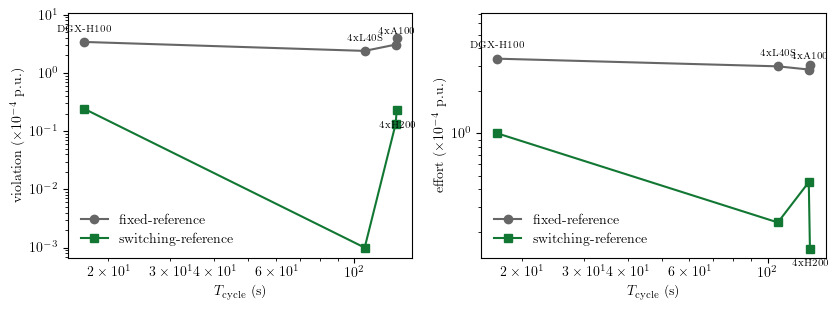

In [9]:
Ts = np.array([r['cycle_s'] for r in table_rows], dtype=float)
viol_fix = np.array([r['fix_viol'] for r in table_rows])
viol_sw  = np.array([r['sw_viol']  for r in table_rows])
eff_fix  = np.array([r['fix_eff']  for r in table_rows])
eff_sw   = np.array([r['sw_eff']   for r in table_rows])

def loglog_slope(T, y):
    mask = y > 1e-6
    if mask.sum() < 2:
        return float('nan')
    slope, _ = np.polyfit(np.log(T[mask]), np.log(y[mask]), 1)
    return slope

print('Log-log slopes:')
print(f"  viol_fix : {loglog_slope(Ts, viol_fix):+.3f}")
print(f"  eff_fix  : {loglog_slope(Ts, eff_fix):+.3f}")
print(f"  viol_sw  : {loglog_slope(Ts, viol_sw):+.3f}")
print(f"  eff_sw   : {loglog_slope(Ts, eff_sw):+.3f}")

trace_names = [r['trace'] for r in table_rows]
LABEL_BELOW = {'4xH200'}
C_SW_PLOT = '#117733'

fig2, ax = plt.subplots(1, 2, figsize=(8.5, 3.2))
for axi, ylab, yf, ys in [(ax[0], r'violation ($\times 10^{-4}$ p.u.)', viol_fix, viol_sw),
                          (ax[1], r'effort ($\times 10^{-4}$ p.u.)',    eff_fix,  eff_sw)]:
    axi.loglog(Ts, yf, 'o-', color='0.4',     label='fixed-reference')
    axi.loglog(Ts, np.maximum(ys, 1e-3), 's-', color=C_SW_PLOT, label='switching-reference')
    axi.set_xlabel(r'$T_{\mathrm{cycle}}$ (s)')
    axi.set_ylabel(ylab)
    axi.legend(frameon=False, loc='lower left')
    for x, t, yh, yl in zip(Ts, trace_names, yf, np.maximum(ys, 1e-3)):
        if t in LABEL_BELOW:
            axi.annotate(t, (x, yl), xytext=(0, -8), textcoords='offset points',
                         fontsize=7, ha='center', va='top')
        else:
            axi.annotate(t, (x, yh), xytext=(0, 6), textcoords='offset points',
                         fontsize=7, ha='center', va='bottom')
    y0, y1 = axi.get_ylim()
    axi.set_ylim(y0, y1 * 1.8)
fig2.tight_layout()
plt.show()

## Two-DC (&sect;V-B.1)

H200 `b16x2` at bus 22, `b8x2` at bus 25. $T_{\mathrm{cycle}} = 132$ s.

Table II  (two-DC; values x1e-4 p.u.)
Controller                  viol       eff
Fixed-reference            6.473     4.807
Switching-reference        0.877     0.252
Improvement                 7.4x     19.1x



-> figures/fig5_two_dc.pdf


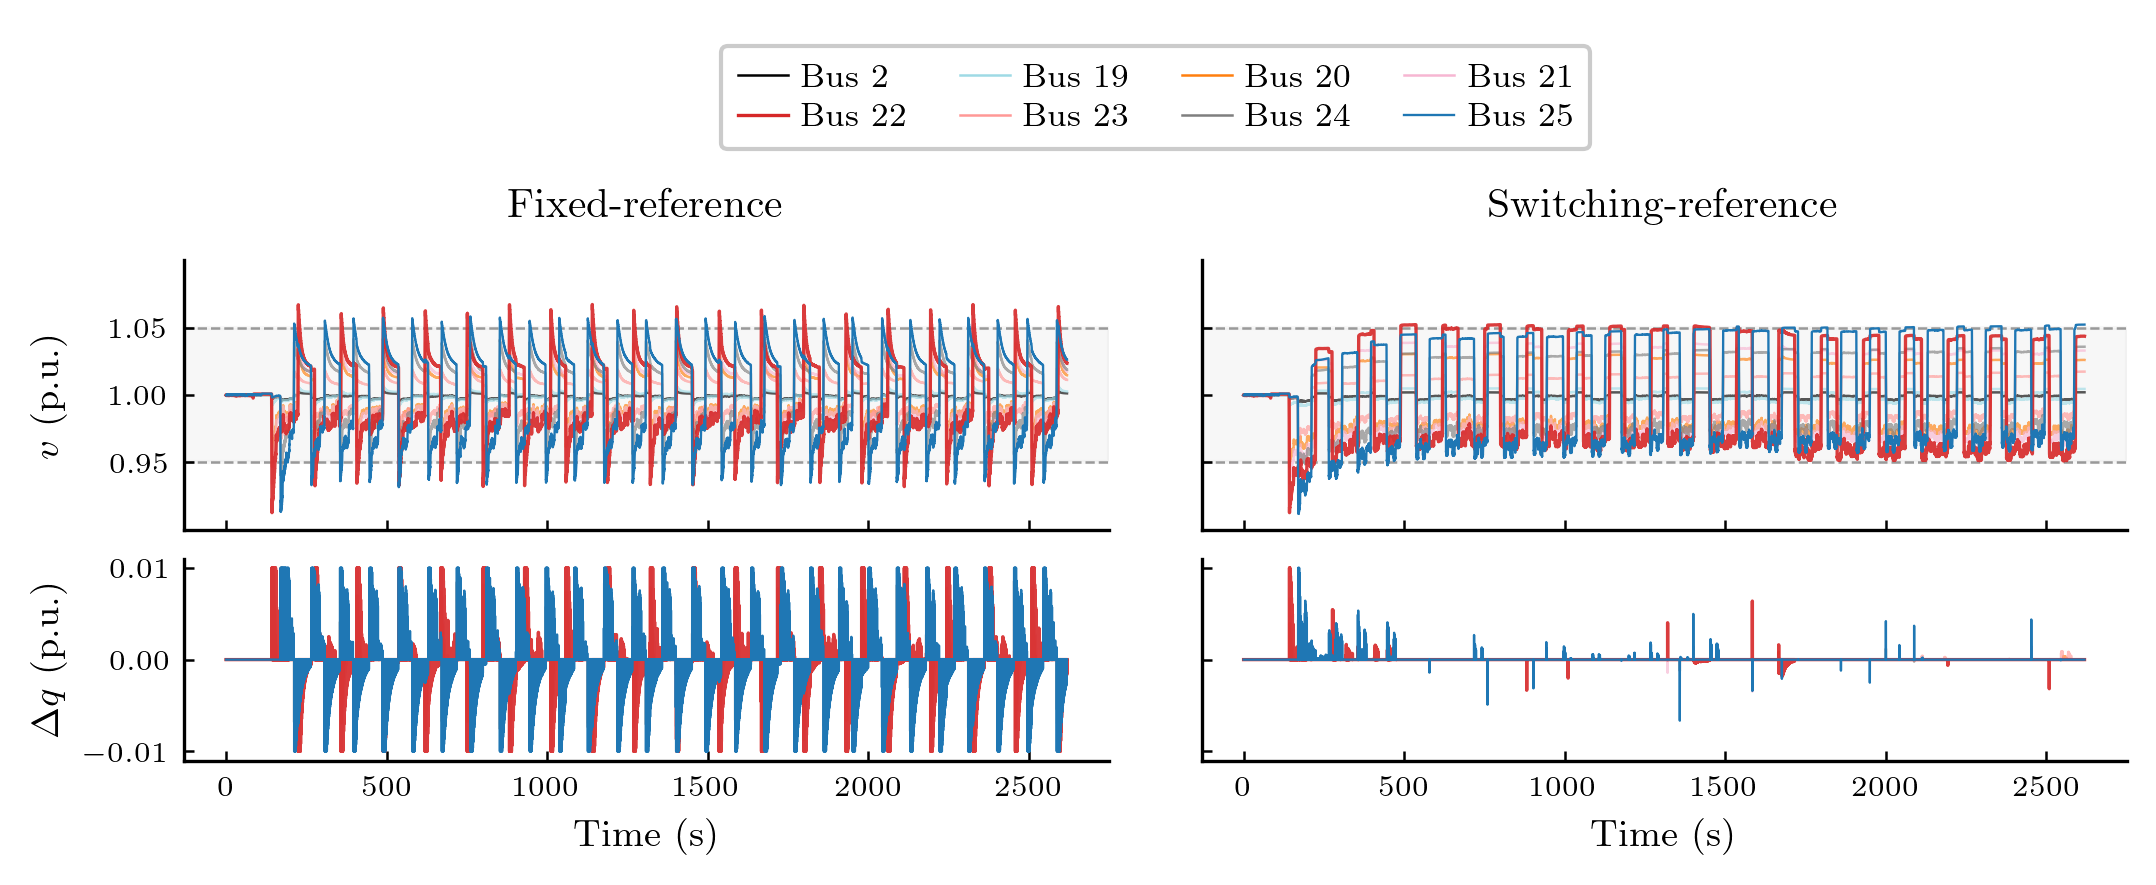

In [10]:
WARMUP_2DC = 6.0 * T_CYCLE_H200

def run_two_dc_fixed(ctx2, ds2):
    V0 = np.zeros((ctx2['num_buses'], 1))
    return closed_loop_two_bus(
        ctx=ctx2, ds=ds2,
        ctrl_step=lambda k, V: action_linear(V, ctx2['K'] * K_SCALE, V0, deadband=DEADBAND),
        stride_ctrl=STRIDE_CTRL,
    )

def run_two_dc_switching(ctx2, ds2, cycle_s):
    dt_ctrl = STRIDE_CTRL * ctx2['dt_sys']
    N_a = max(1, int(round(ALPHA * cycle_s / dt_ctrl)))
    N_b = max(1, int(round(BETA  * cycle_s / dt_ctrl)))
    D_b = max(1, int(round(GAMMA * cycle_s / dt_ctrl)))
    ctx2['env'].reset(P=ctx2['P0_INIT'], balance_Q=True)
    ctrl = AdaRefVBiasAmpMaxDV(
        n=ctx2['num_buses'], K=ctx2['K'] * K_SCALE,
        action_kwargs={'deadband': DEADBAND},
        bias_len=N_b, bias_per=D_b, bias_frac=ETA_B,
        amp_win_len=N_a,
    )
    return closed_loop_two_bus(
        ctx=ctx2, ds=ds2,
        ctrl_step=lambda k, V: ctrl.step(V),
        stride_ctrl=STRIDE_CTRL,
        vref_getter=lambda: ctrl.V_ref,
    )

ctx2 = setup_two_bus(); ds2 = load_two_bus(ctx2)
res_fix = run_two_dc_fixed(ctx2, ds2)
ctx2 = setup_two_bus(); ds2 = load_two_bus(ctx2)
res_sw  = run_two_dc_switching(ctx2, ds2, cycle_s=T_CYCLE_H200)

m_fix = compute_metrics(res_fix['record_dQ'], res_fix['record_V'],
                        dt=ctx2['env'].dt, warmup_secs=WARMUP_2DC)
m_sw  = compute_metrics(res_sw['record_dQ'],  res_sw['record_V'],
                        dt=ctx2['env'].dt, warmup_secs=WARMUP_2DC)

print('=' * 70)
print('Table II  (two-DC; values x1e-4 p.u.)')
print('=' * 70)
print(f"{'Controller':<22}{'viol':>10}{'eff':>10}")
print(f"{'Fixed-reference':<22}{m_fix['rms_excess']*1e4:>10.3f}{m_fix['rms_dq']*1e4:>10.3f}")
print(f"{'Switching-reference':<22}{m_sw['rms_excess']*1e4:>10.3f}{m_sw['rms_dq']*1e4:>10.3f}")
vr = m_fix['rms_excess'] / m_sw['rms_excess'] if m_sw['rms_excess'] > 1e-8 else float('inf')
er = m_fix['rms_dq'] / m_sw['rms_dq']
print(f"{'Improvement':<22}{vr:>9.1f}x{er:>9.1f}x")

# Fig 5 (two-DC time-domain)
runs_2dc = [
    {'dQ': res_fix['record_dQ'], 'V': res_fix['record_V'], 'dc_buses': ctx2['dc_buses']},
    {'dQ': res_sw['record_dQ'],  'V': res_sw['record_V'],  'dc_buses': ctx2['dc_buses']},
]
out_fig5 = FIG_DIR / 'fig5_two_dc.pdf'
plot_publication_scenario_2col(
    runs_2dc,
    bus_colors=ctx2['bus_colors'],
    plot_buses=SUB_BUSES_DEFAULT,
    save_path=str(out_fig5),
    dt=ctx2['env'].dt,
)
print('\n-> figures/fig5_two_dc.pdf')
plt.show()

## Fig 6: load smoothing (&sect;V-B.2)

4&times;H200 head + storage-regulated tail. Switching-ref adapts across the regime change without retuning.

Exp 3 (switching-ref on regulated tail):
  rms_excess = 0.321e-4
  rms_dq     = 0.308e-4
  violation_rate = 6.88%


-> figures/fig6_load_smoothing.pdf


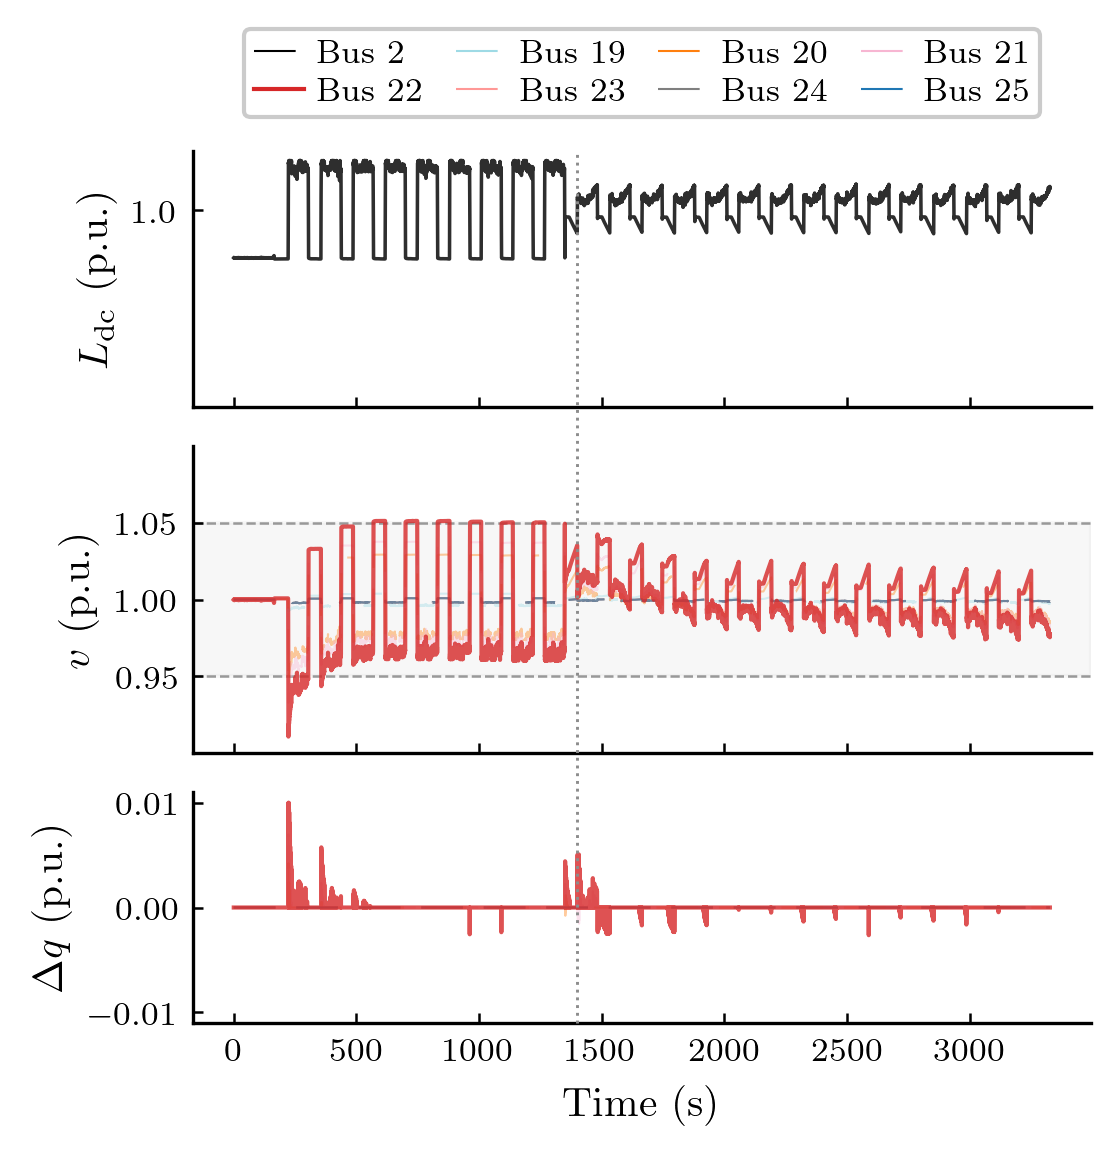

In [11]:
ctx = setup_common(); ds = load_h200_regulated(ctx)
warm = 6.0 * T_CYCLE_H200

dt_ctrl = STRIDE_CTRL * ctx['dt_sys']
N_a = max(1, int(round(ALPHA * T_CYCLE_H200 / dt_ctrl)))
N_b = max(1, int(round(BETA  * T_CYCLE_H200 / dt_ctrl)))
D_b = max(1, int(round(GAMMA * T_CYCLE_H200 / dt_ctrl)))
ctrl = AdaRefVBiasAmpMaxDV(
    n=ctx['num_buses'], K=ctx['K'] * K_SCALE,
    action_kwargs={'deadband': DEADBAND},
    bias_len=N_b, bias_per=D_b, bias_frac=ETA_B,
    amp_win_len=N_a,
)
dQ_e, V_e = closed_loop(ctx=ctx, ds=ds,
                        ctrl_step=lambda k, V: ctrl.step(V),
                        stride_ctrl=STRIDE_CTRL)
m_e = compute_metrics(dQ_e, V_e, dt=ctx['env'].dt, warmup_secs=warm)
print('Exp 3 (switching-ref on regulated tail):')
print(f"  rms_excess = {m_e['rms_excess']*1e4:.3f}e-4")
print(f"  rms_dq     = {m_e['rms_dq']*1e4:.3f}e-4")
print(f"  violation_rate = {m_e['violation_rate']*100:.2f}%")

# Sign-flip ds['pwr_pwr'] (negative-by-convention in the loader) and
# center it near 1.0 p.u. so the L_dc panel reads as a normalized load trace.
_t = ds['t_pwr']
_p = -np.asarray(ds['pwr_pwr'])
_p = _p + (1.0 - float(np.median(_p))) + 0.05

out_fig6 = FIG_DIR / 'fig6_load_smoothing.pdf'
plot_publication_loadsmooth_sc(
    _t, _p, dQ_e, V_e,
    bus_colors=ctx['bus_colors'],
    plot_buses=SUB_BUSES_DEFAULT,
    dc_buses=[ctx['dc_bus']],
    save_path=str(out_fig6),
    dt=ctx['env'].dt,
    smoothing_onset=1400.0,
)
print('-> figures/fig6_load_smoothing.pdf')
plt.show()